In [ ]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn
import tensorflow as tf

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("Scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)

# Biometric Scanner

## 1. Dataset Inspection

This section loads and verifies the custom face-image dataset before preprocessing and model training.

In [1]:
from pathlib import Path
from PIL import Image

# Dataset paths
DATA_DIR = Path("../data/raw")

OPERATOR_DIR = DATA_DIR / "operator"
NON_OPERATOR_DIR = DATA_DIR / "non_operator"

print("Operator directory:", OPERATOR_DIR)
print("Non-operator directory:", NON_OPERATOR_DIR)


Operator directory: ..\data\raw\operator
Non-operator directory: ..\data\raw\non_operator


In [2]:
operator_images = list(OPERATOR_DIR.glob("*"))
non_operator_images = list(NON_OPERATOR_DIR.glob("*"))

print("Operator images:", len(operator_images))
print("Non-operator images:", len(non_operator_images))
print("Total images:", len(operator_images) + len(non_operator_images))


Operator images: 30
Non-operator images: 30
Total images: 60


In [3]:
def check_images(image_paths):
    valid = []
    invalid = []

    for path in image_paths:
        try:
            with Image.open(path) as img:
                img.verify()
            valid.append(path)
        except Exception as e:
            invalid.append((path, str(e)))

    return valid, invalid


operator_valid, operator_invalid = check_images(operator_images)
non_operator_valid, non_operator_invalid = check_images(non_operator_images)

print("Operator:")
print("  Valid:", len(operator_valid))
print("  Invalid:", len(operator_invalid))

print("\nNon-operator:")
print("  Valid:", len(non_operator_valid))
print("  Invalid:", len(non_operator_invalid))

Operator:
  Valid: 30
  Invalid: 0

Non-operator:
  Valid: 30
  Invalid: 0


In [4]:
from collections import Counter

def get_dimensions(image_paths):
    dimensions = []

    for path in image_paths:
        with Image.open(path) as img:
            dimensions.append(img.size)

    return dimensions


operator_dimensions = get_dimensions(operator_valid)
non_operator_dimensions = get_dimensions(non_operator_valid)

print("Operator dimensions:")
print(Counter(operator_dimensions))

print("\nNon-operator dimensions:")
print(Counter(non_operator_dimensions))


Operator dimensions:
Counter({(4000, 2252): 29, (4000, 3000): 1})

Non-operator dimensions:
Counter({(250, 250): 30})


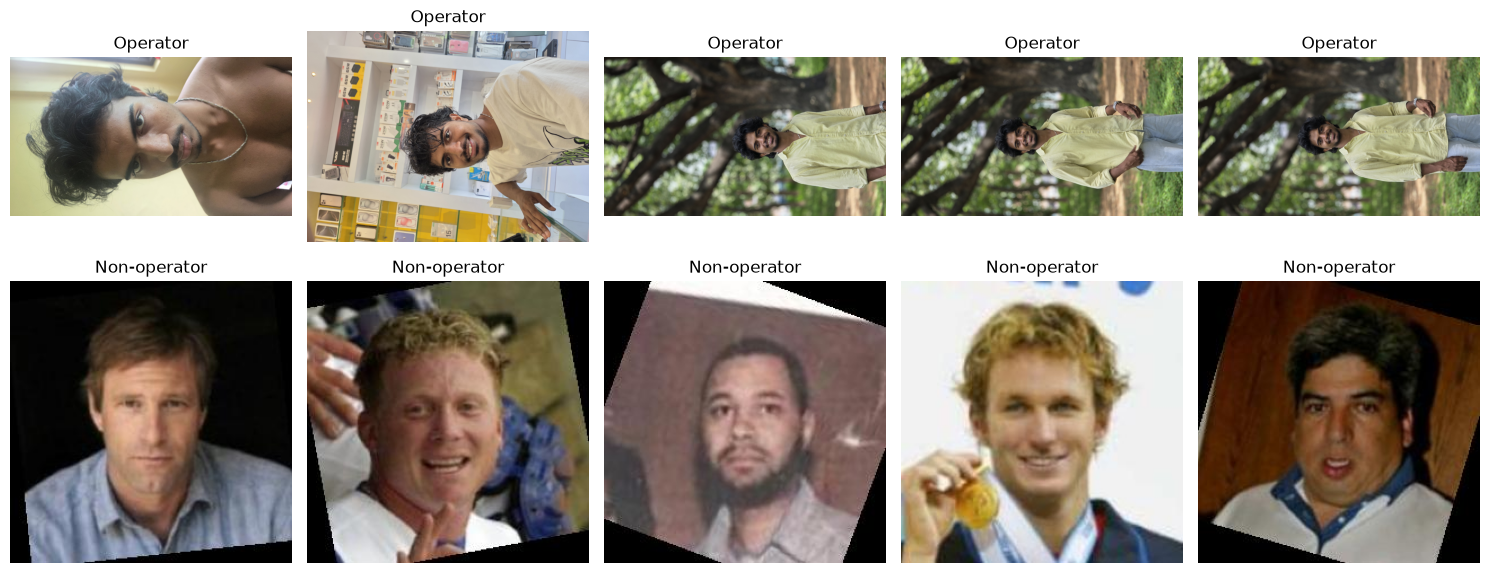

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, path in zip(axes[0], operator_valid[:5]):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title("Operator")
    ax.axis("off")

for ax, path in zip(axes[1], non_operator_valid[:5]):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title("Non-operator")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 2. Data Preprocessing

The images are converted into a consistent format and size before being supplied to the machine learning model.

In [6]:
IMG_SIZE = (224, 224)

In [7]:
import numpy as np
from PIL import Image

def load_and_preprocess(image_paths, label):
    images = []
    labels = []

    for path in image_paths:
        try:
            image = Image.open(path).convert("RGB")
            image = image.resize(IMG_SIZE)

            image = np.array(image, dtype=np.float32) / 255.0

            images.append(image)
            labels.append(label)

        except Exception as e:
            print(f"Error processing {path}: {e}")

    return np.array(images), np.array(labels)

In [8]:
operator_X, operator_y = load_and_preprocess(
    operator_valid, 
    label=1
)

non_operator_X, non_operator_y = load_and_preprocess(
    non_operator_valid, 
    label=0
)

In [9]:
print("Operator shape:", operator_X.shape)
print("Non-operator shape:", non_operator_X.shape)

Operator shape: (30, 224, 224, 3)
Non-operator shape: (30, 224, 224, 3)


In [10]:
X = np.concatenate([operator_X, non_operator_X])
y = np.concatenate([operator_y, non_operator_y])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", y)

X shape: (60, 224, 224, 3)
y shape: (60,)
Labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape[0])
print("Testing:", X_test.shape[0])

Training: 48
Testing: 12


## 3. Transfer Learning Model

A pretrained MobileNetV2 network is used as the feature extractor. A custom classification head is added to distinguish between the operator and non-operator classes.

The pretrained base is initially kept frozen to reduce overfitting on the small custom dataset.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [13]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 4. Data Augmentation

Because the custom dataset is small, data augmentation is applied to the training images to introduce controlled variations and reduce overfitting.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=8,
    callbacks=[early_stopping],
    shuffle=True
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.5000 - loss: 0.9079 - val_accuracy: 0.4000 - val_loss: 1.0989
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5789 - loss: 0.7057 - val_accuracy: 0.5000 - val_loss: 1.0677
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - accuracy: 0.5000 - loss: 0.8887 - val_accuracy: 0.5000 - val_loss: 1.0433
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - accuracy: 0.5526 - loss: 0.7396 - val_accuracy: 0.5000 - val_loss: 1.0191
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 467ms/step - accuracy: 0.5263 - loss: 0.8233 - val_accuracy: 0.5000 - val_loss: 0.9980
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.4737 - loss: 0.8414 - val_accuracy: 0.5000 - val_loss: 0.9747
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms/step - accuracy: 0.5526 - loss: 0.7615 - val_accuracy: 0.5000 - val_loss: 0.9537
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.6316 - loss: 0.6444 - val_accuracy: 0.5000 - val_loss: 

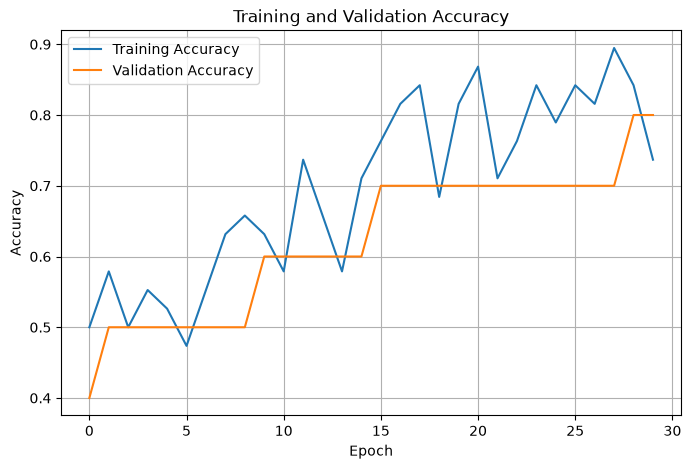

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

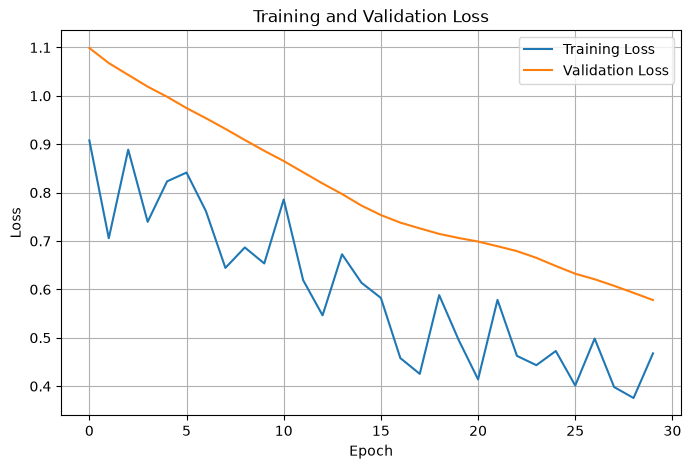

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## 5. Test Set Evaluation

The trained model is evaluated on the held-out test set, which was not used during model training or validation.

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8333 - loss: 0.3541
Test Loss: 0.3540862500667572
Test Accuracy: 0.8333333134651184


## 6. Classification Metrics and Confusion Matrix

The model predictions on the held-out test set are used to calculate precision, recall, F1-score, and the confusion matrix.

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Generate probabilities
y_prob = model.predict(X_test)

# Convert probabilities to binary predictions
y_pred = (y_prob >= 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-operator", "Operator"],
        zero_division=0
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
Accuracy:  0.8333
Precision: 0.7500
Recall:    1.0000
F1-score:  0.8571

Classification Report:
              precision    recall  f1-score   support

Non-operator       1.00      0.67      0.80         6
    Operator       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12



In [26]:
import seaborn as sns

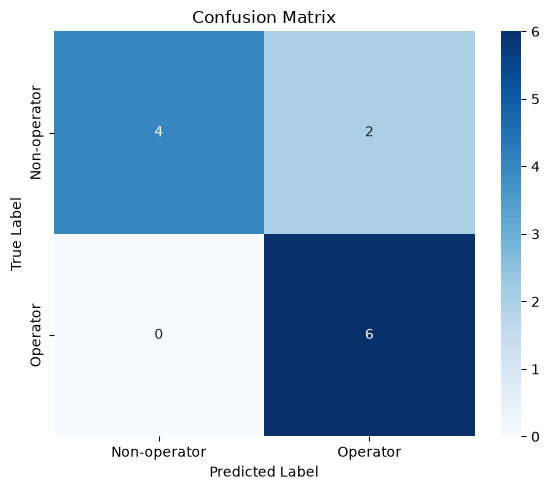

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-operator", "Operator"],
    yticklabels=["Non-operator", "Operator"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

In [28]:
wrong_indices = np.where(y_test != y_pred)[0]

print("Number of incorrect predictions:", len(wrong_indices))

for i in wrong_indices:
    print(
        f"Test index: {i} | "
        f"Actual: {'Operator' if y_test[i] == 1 else 'Non-operator'} | "
        f"Predicted: {'Operator' if y_pred[i] == 1 else 'Non-operator'} | "
        f"Probability: {y_prob[i][0]:.4f}"
    )

Number of incorrect predictions: 2
Test index: 0 | Actual: Non-operator | Predicted: Operator | Probability: 0.5593
Test index: 7 | Actual: Non-operator | Predicted: Operator | Probability: 0.5117


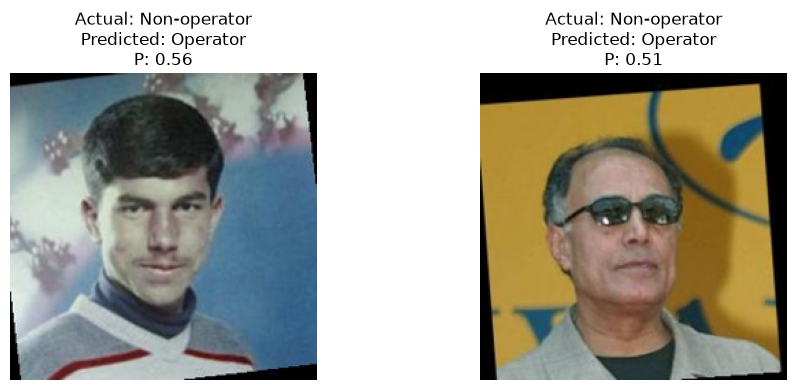

In [29]:
plt.figure(figsize=(10, 4))

for plot_index, test_index in enumerate(wrong_indices):
    plt.subplot(1, len(wrong_indices), plot_index + 1)
    plt.imshow(X_test[test_index])
    
    actual = "Operator" if y_test[test_index] == 1 else "Non-operator"
    predicted = "Operator" if y_pred[test_index] == 1 else "Non-operator"
    
    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"P: {y_prob[test_index][0]:.2f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [30]:
model.save("../models/biometric_scanner.keras")

print("Model saved successfully.")

Model saved successfully.


## 7. Inference

The trained model is used to classify a new face image as either an operator or a non-operator.

In [31]:
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np

# Load the saved model
inference_model = load_model("../models/biometric_scanner.keras")

print("Model loaded successfully.")

Model loaded successfully.


In [32]:
def predict_face(image_path, model, threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))

    image_array = np.array(image, dtype=np.float32) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    probability = model.predict(image_array, verbose=0)[0][0]

    if probability >= threshold:
        result = "Operator"
    else:
        result = "Non-operator"

    return result, probability

In [34]:
test_image = "../data/raw/operator/operator_01.jpg"

result, probability = predict_face(
    test_image,
    inference_model
)

print("Prediction:", result)
print(f"Probability: {probability:.4f}")

Prediction: Operator
Probability: 0.8318


In [35]:
test_image = "../data/raw/non_operator/non_operator_01.jpg"

result, probability = predict_face(
    test_image,
    inference_model
)

print("Prediction:", result)
print(f"Probability: {probability:.4f}")


Prediction: Non-operator
Probability: 0.4100


In [36]:
from pathlib import Path

SAMPLE_DIR = Path("../results/sample_predictions")
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

print("Sample prediction directory ready:", SAMPLE_DIR)

Sample prediction directory ready: ..\results\sample_predictions


In [37]:
for i in range(len(X_test)):
    probability = float(y_prob[i][0])
    
    actual = "Operator" if y_test[i] == 1 else "Non-operator"
    predicted = "Operator" if y_pred[i] == 1 else "Non-operator"

    plt.figure(figsize=(5, 5))
    plt.imshow(X_test[i])
    plt.axis("off")
    
    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Probability: {probability:.2f}"
    )

    output_path = SAMPLE_DIR / f"prediction_{i+1:02d}.png"
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close()

print(f"Saved {len(X_test)} sample prediction images.")

Saved 12 sample prediction images.


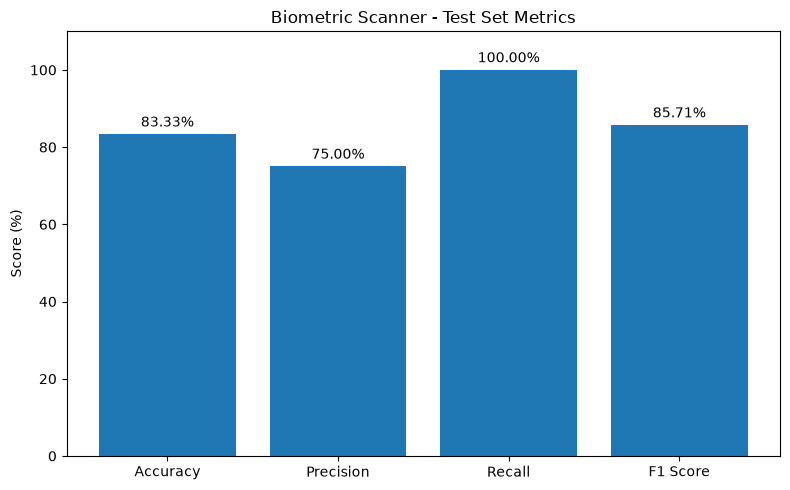

In [38]:
import matplotlib.pyplot as plt
from pathlib import Path

# Final evaluation metrics
metrics = {
    "Accuracy": 83.33,
    "Precision": 75.00,
    "Recall": 100.00,
    "F1 Score": 85.71
}

# Create results directory if it doesn't exist
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Create metrics chart
plt.figure(figsize=(8, 5))

bars = plt.bar(metrics.keys(), metrics.values())

plt.ylim(0, 110)
plt.ylabel("Score (%)")
plt.title("Biometric Scanner - Test Set Metrics")

# Add values above bars
for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

# Save image
plt.savefig(
    results_dir / "metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()